# 2D Multi-Axial IsoDiffusion Conditional Reconstruction

Patch-based 3D conditional diffusion over overlapping subvolumes, with each subvolume sliced for a 2D multi-axial UNet before guided DDIM updates.

## 1. Imports & Setup


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm.auto import tqdm

PROJECT_ROOT = Path('/myhome/sdate')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import lovely_tensors as lt
lt.monkey_patch()

from isodiffusion.fourier_wedge import enforce_known_fourier
from isodiffusion.recon_utils import (
    iter_patch_slices,
    load_npy_volume,
    load_norm_fns_from_checkpoint_sidecar,
    load_unet2d,
)
from isodiffusion.schedulers.pipeline_ddim_2d import DDIMPipeline2D as DDIMPipeline
from isodiffusion.schedulers.scheduling_ddim import GuidedDDIMScheduler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

## 2. Configuration


In [2]:
# Edit these paths/parameters for the current run.
condition_volume_path = Path('/myhome/data/sdate/shared/compression_paper/file_1_extracted/reconstruction/la_fourier_1.npy')
ground_truth_volume_path = Path('/myhome/data/sdate/shared/compression_paper/file_1_extracted/reconstruction/gt_fbp_1.npy')
initial_volume_path = None  # or Path('/path/to/previous_estimate.npy')
checkpoint_path = Path('/myhome/sdate/checkpoints/ddpm_isodiffusion2d_f1_2d.pt')
output_path = PROJECT_ROOT / 'outputs' / 'isodiffusion_recon_2d.npy'

patch_size = 192
volume_batch_size = 5
preview_batch_index = 0

# Debug controls for the cells below.
history_every = 10
guidance_source = 'ground_truth'  # 'ground_truth' matches the old oracle helper; use 'condition' to debug measured-data guidance.
use_identity_guidance = False

# If left as None, these are inferred from the checkpoint sidecar.
angular_range_deg = None
start_angle_deg = None
tilt_axis = None

## 3. Load Model, Normalization, and Volumes


In [3]:
model, config = load_unet2d(checkpoint_path, device=device)
normalize_fn, denormalize_fn, norm_config = load_norm_fns_from_checkpoint_sidecar(checkpoint_path)

normalize_fn(torch.ones(10, 10))

tensor[10, 10] n=100 x∈[1.555e+03, 1.555e+03] μ=1.555e+03 σ=0.

In [4]:
if angular_range_deg is None:
    cone_width_deg = float(norm_config.get('cone_width_deg', 72.0))
    angular_range_deg = 180.0 - cone_width_deg
if start_angle_deg is None:
    cone_width_deg = float(norm_config.get('cone_width_deg', 72.0))
    center = float(norm_config.get('carve_center_angle_deg', 0.0))
    start_angle_deg = (center + cone_width_deg / 2.0) % 180.0
if tilt_axis is None:
    tilt_axis = int(norm_config.get('tilt_axis', 0))

condition = load_npy_volume(condition_volume_path)
ground_truth = load_npy_volume(ground_truth_volume_path)
initial = condition.clone() if initial_volume_path is None else load_npy_volume(initial_volume_path)

print(f'model parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'volume shape: {tuple(condition.shape)}')
print(f'volume batch size: {volume_batch_size}')
print(dict(angular_range_deg=angular_range_deg, start_angle_deg=start_angle_deg, tilt_axis=tilt_axis))


model parameters: 28,527,937
volume shape: (540, 640, 640)
volume batch size: 5
{'angular_range_deg': 108.0, 'start_angle_deg': 36.0, 'tilt_axis': 0}


## 4. Crop Debug Volume


In [5]:
# start = 300
# condition = condition[start:start + patch_size, start:start + patch_size, start:start + patch_size]
# initial = initial[start:start + patch_size, start:start + patch_size, start:start + patch_size]
# ground_truth = ground_truth[start:start + patch_size, start:start + patch_size, start:start + patch_size]
# condition, initial, ground_truth

# # For a quick debug crop, keep one model-sized slab. For full inference, comment this cell out.
# condition = condition[patch_size:patch_size + patch_size]
# initial = initial[patch_size:patch_size + patch_size]
# ground_truth = ground_truth[patch_size:patch_size + patch_size]
# condition, initial, ground_truth

## 5. Patch Geometry

`reconstruct_volume_patches` builds this list internally. Keeping it visible makes it easy to inspect the exact patch batch that enters the denoiser.


In [6]:
overlap = 10
patch_slices = list(iter_patch_slices(condition.shape[-3:], patch_size, overlap))
debug_patch_index = 27
debug_patch_index = min(debug_patch_index, len(patch_slices) - 1)
debug_slc = patch_slices[debug_patch_index]

def make_volume_batch(volume: torch.Tensor, batch_size: int) -> torch.Tensor:
    if volume.ndim == 3:
        return volume.unsqueeze(0).repeat(batch_size, 1, 1, 1).contiguous()
    if volume.ndim == 4:
        if volume.shape[0] != batch_size:
            raise ValueError(f'batched volume has batch size {volume.shape[0]}, expected {batch_size}')
        return volume.contiguous()
    raise ValueError(f'expected (D, H, W) or (bs, D, H, W), got {tuple(volume.shape)}')

condition_batch = make_volume_batch(condition, volume_batch_size)
initial_batch = make_volume_batch(initial, volume_batch_size)
ground_truth_batch = make_volume_batch(ground_truth, volume_batch_size)

debug_initial = initial_batch[:, debug_slc[0], debug_slc[1], debug_slc[2]]
debug_condition = condition_batch[:, debug_slc[0], debug_slc[1], debug_slc[2]]
debug_ground_truth = ground_truth_batch[:, debug_slc[0], debug_slc[1], debug_slc[2]]

debug_slice_index = debug_ground_truth.shape[1] // 2
debug_initial_slice = debug_initial[:, debug_slice_index]
debug_condition_slice = debug_condition[:, debug_slice_index]
debug_ground_truth_slice = debug_ground_truth[:, debug_slice_index]

print(f'patches per volume: {len(patch_slices)}')
print(f'total packed subvolumes: {volume_batch_size * len(patch_slices)}')
print(f'debug patch {debug_patch_index}: {debug_slc}')
print(f'debug patch batch shape: {tuple(debug_condition.shape)}')
print(f'debug axial slice shape: {tuple(debug_condition_slice.shape)}')

patches per volume: 48
total packed subvolumes: 240
debug patch 27: (slice(182, 374, None), slice(364, 556, None), slice(448, 640, None))
debug patch batch shape: (5, 192, 192, 192)
debug axial slice shape: (5, 192, 192)


## 6. Full-Volume Guidance Function

The 2D `DDIMPipeline` partitions the UNet call into 3D subvolumes first, then slices each subvolume along a scheduled axis. The scheduler keeps the raw state as `(bs, D, H, W)`, so `guidance(x_0_raw, t)` receives and returns the same full-volume batch shape.

In [7]:
def select_guidance_volume(condition_volume: torch.Tensor, ground_truth_volume: torch.Tensor) -> torch.Tensor:
    if guidance_source == 'ground_truth':
        return ground_truth_volume
    if guidance_source == 'condition':
        return condition_volume
    raise ValueError("guidance_source must be 'ground_truth' or 'condition'")


def fourier_guidance(
    source_volume: torch.Tensor,
    vol_init: torch.Tensor,
    timestep: int = 0,
) -> torch.Tensor:
    if vol_init.ndim == 3:
        if source_volume.ndim == 4:
            source_volume = source_volume[0]
        return enforce_known_fourier(
            estimate_volume=vol_init,
            measured_volume=source_volume.to(vol_init.device, dtype=vol_init.dtype),
            angular_range_deg=angular_range_deg,
            start_angle_deg=start_angle_deg,
            tilt_axis=tilt_axis,
        )

    if vol_init.ndim != 4:
        raise ValueError(f'guidance expects (D, H, W) or (bs, D, H, W), got {tuple(vol_init.shape)}')

    if source_volume.ndim == 3:
        source_volume = source_volume.unsqueeze(0).expand(vol_init.shape[0], -1, -1, -1)
    if source_volume.ndim != 4 or source_volume.shape[0] != vol_init.shape[0]:
        raise ValueError(
            f'source volume shape {tuple(source_volume.shape)} is incompatible with estimate shape {tuple(vol_init.shape)}'
        )

    guided = [
        enforce_known_fourier(
            estimate_volume=estimate,
            measured_volume=measured.to(estimate.device, dtype=estimate.dtype),
            angular_range_deg=angular_range_deg,
            start_angle_deg=start_angle_deg,
            tilt_axis=tilt_axis,
        )
        for estimate, measured in zip(vol_init, source_volume)
    ]
    return torch.stack(guided, dim=0)


guidance_source_volume = select_guidance_volume(condition_batch, ground_truth_batch)

def guidance(x_0_raw: torch.Tensor, timestep: int) -> torch.Tensor:
    if use_identity_guidance:
        return x_0_raw
    x =  fourier_guidance(
        source_volume=guidance_source_volume,
        vol_init=x_0_raw,
        timestep=int(timestep),
    )
    x = x.mean(dim=0).repeat(x.shape[0], 1, 1, 1)
    return x

print(f'guidance source: {guidance_source}')
print(f'guidance batch shape: {tuple(guidance_source_volume.shape)}')


guidance source: ground_truth
guidance batch shape: (5, 540, 640, 640)


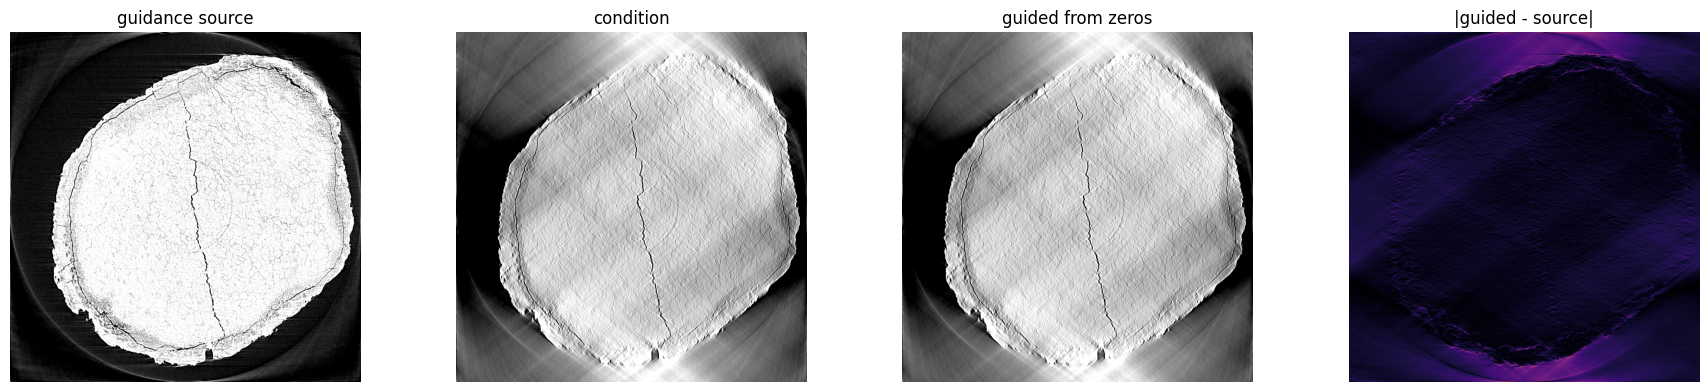

In [8]:
# Quick guidance sanity check from zero initialisation on the full crop batch.
with torch.no_grad():
    zeros_raw = torch.zeros_like(guidance_source_volume)
    guided_from_zeros = guidance(zeros_raw.to(device), 0).cpu()

preview_idx = min(preview_batch_index, guided_from_zeros.shape[0] - 1)
guidance_preview = guidance_source_volume[preview_idx].cpu()
condition_preview = condition_batch[preview_idx].cpu()
guided_preview = guided_from_zeros[preview_idx]

z = guided_preview.shape[0] // 2
# vmin, vmax = np.percentile(guidance_source_volume.numpy(), [1, 99])
vmin, vmax = norm_config["norm_min"], 5 * norm_config["norm_max"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(guidance_preview[z], cmap='gray', vmin=vmin, vmax=vmax)
axes[0].set_title('guidance source')
axes[1].imshow(condition_preview[z], cmap='gray', vmin=vmin, vmax=vmax)
axes[1].set_title('condition')
axes[2].imshow(guided_preview[z], cmap='gray', vmin=vmin, vmax=vmax)
axes[2].set_title('guided from zeros')
axes[3].imshow((guided_preview[z] - guidance_preview[z]).abs(), cmap='magma')
axes[3].set_title('|guided - source|')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
torch.cuda.empty_cache()


tensor[5, 1, 192, 192] n=184320 (0.7Mb) x∈[-4.794, 5.310] μ=0.449 σ=1.037 cuda:0

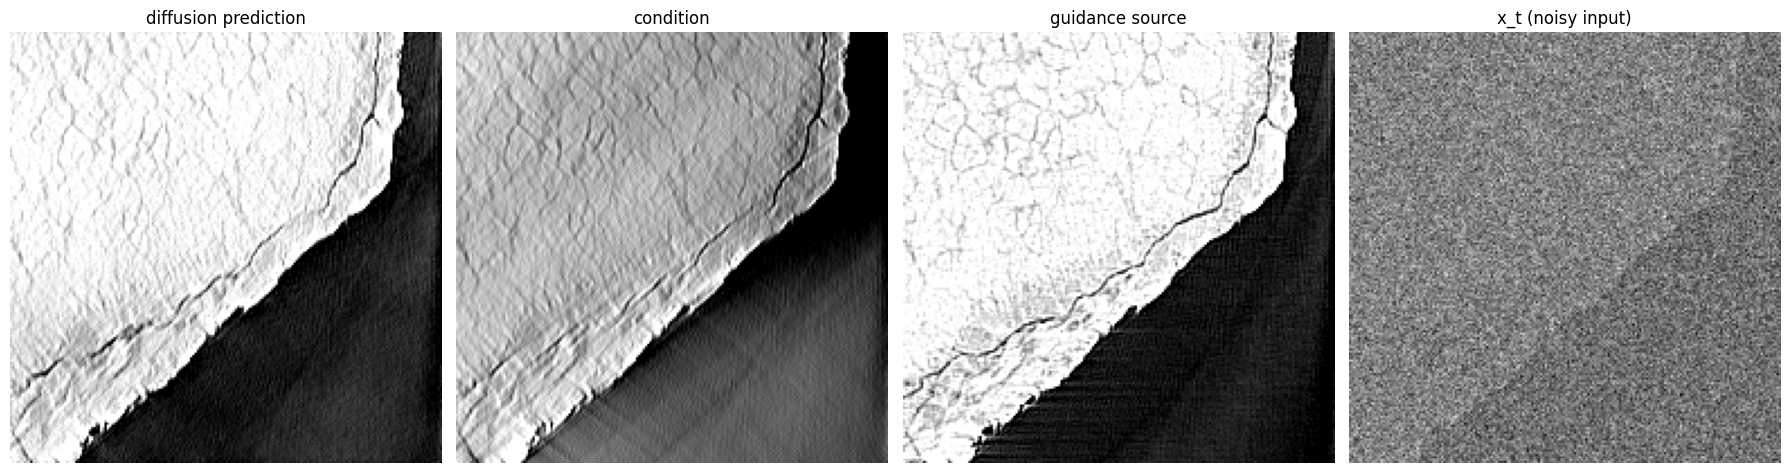

In [9]:
torch.cuda.empty_cache()
NUM_INFERENCE_STEPS = 50
scheduler = GuidedDDIMScheduler(1000, clip_sample_range=5)
scheduler.set_timesteps(NUM_INFERENCE_STEPS)
timestep = 600

x = normalize_fn(debug_ground_truth_slice.float().unsqueeze(1)).to(device)
conditioning = normalize_fn(debug_condition_slice.float().unsqueeze(1)).to(device)
timesteps = torch.full((x.shape[0],), timestep, device=device, dtype=torch.long)
x_t = scheduler.add_noise(x, torch.randn_like(x), timesteps=timesteps)

with torch.no_grad():
    model_input = torch.cat([x_t, conditioning], dim=1)
    class_labels = torch.ones((model_input.shape[0],), device=device, dtype=torch.long)
    noise_pred = model(
        model_input,
        timestep=timesteps,
        class_labels=class_labels,
        return_dict=False,
    )[0]
    x_0_pred = scheduler.step(noise_pred, timestep=timestep, sample=x_t).pred_original_sample
    diffusion_pred = denormalize_fn(x_0_pred)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(diffusion_pred[0, 0].cpu(), cmap='gray', vmin=vmin, vmax=vmax)
axes[0].set_title('diffusion prediction')
axes[1].imshow(debug_condition_slice[0], cmap='gray', vmin=vmin, vmax=vmax)
axes[1].set_title('condition')
axes[2].imshow(debug_ground_truth_slice[0], cmap='gray', vmin=vmin, vmax=vmax)
axes[2].set_title('guidance source')
axes[3].imshow(x_t[0, 0].cpu(), cmap='gray')
axes[3].set_title('x_t (noisy input)')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
x_t

## 7. Run Guided DDIM Pipeline

Create a `GuidedDDIMScheduler`, pass it into the 2D `DDIMPipeline`, then call `truncated_pipeline(...)` on the current full-volume estimate. The pipeline cycles slice orientations so the last denoising step is axial.

In [10]:
overlap = 10
slice_batch_size = 100
axial_only = True
num_inference_steps = 10
start_step_frac = 0.01
num_outer_iters = 1

In [11]:
# guidance = lambda x_0, t: x_0  # identity guidance for testing the rest of the pipeline without the Fourier constraint.

In [ ]:
torch.cuda.empty_cache()

noise_scheduler = GuidedDDIMScheduler(
    num_train_timesteps=1000,
    guidance_function=guidance,
    clip_sample_range=6
)

pipeline = DDIMPipeline(
    unet=model.to(device),
    scheduler=noise_scheduler,
    conditioning=condition_batch.to(device),
    normalize_fn=normalize_fn,
    denormalize_fn=denormalize_fn,
    slice_batch_size=slice_batch_size,
    overlap=overlap,
    patch_size=patch_size,
    axial_only=axial_only,
)

recon = initial_batch.float()

result = pipeline.truncated_pipeline(
    initial_guess=recon.to(device),
    start_step=int(start_step_frac * num_inference_steps),
    num_inference_steps=num_inference_steps,
    use_clipped_model_output=True,
)
recon = result.images

output_path.parent.mkdir(parents=True, exist_ok=True)
np.save(output_path, recon.numpy().astype(np.float32))

print(f'Guided DDIM reconstruction done')
print(f'  shape: {tuple(recon.shape)}')
print(f'  range: [{recon.min():.4f}, {recon.max():.4f}]')
output_path

  0%|          | 0/10 [00:00<?, ?it/s]

## 8. Visualise Result


In [ ]:
from ipywidgets import interact
import ipywidgets as widgets

preview_idx = min(preview_batch_index, recon.shape[0] - 1)
recon_preview = recon[preview_idx]
condition_preview = condition_batch[preview_idx]
ground_truth_preview = ground_truth_batch[preview_idx]

vmin, vmax = np.percentile(condition_preview.numpy(), [1, 99])

def visualize_slice(z):
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    axes[0].imshow(condition_preview[z], cmap='gray', vmin=vmin, vmax=vmax)
    axes[0].set_title('condition')
    axes[1].imshow(recon_preview[z], cmap='gray', vmin=vmin, vmax=vmax)
    axes[1].set_title('isodiffusion')
    axes[2].imshow(ground_truth_preview[z], cmap='gray', vmin=vmin, vmax=vmax)
    axes[2].set_title('ground truth')
    axes[3].imshow((recon_preview[z] - ground_truth_preview[z]).abs(), cmap='magma')
    axes[3].set_title('|error|')
    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

max_z = recon_preview.shape[0] - 1
interact(visualize_slice, z=widgets.IntSlider(min=0, max=max_z, step=1, value=max_z//2))